# 17. Modeles a raisonnement natif vs scaling du test-time compute

**Phase 5 de l'epic #2926** — suite de **NB-12** (moteurs), **NB-16** (scaling pass@k).

## La question centrale de Snell (Phase 5)

NB-16 a mesure que le **test-time compute exterieur** (BoN, Reflexion) se met a l'echelle :
plus d'echantillons = plus de succes (la ou il y a de la marge). Mais les **modeles a
raisonnement natif** (deepseek-r1, o1/o3, gpt-5-thinking) depensent leur test-time compute
**a l'interieur** : ils generent des **tokens de raisonnement caches** avant la reponse.

> **Question (Snell)** : a **cout egal** (en tokens, raisonnement inclus), un modele a
> raisonnement natif bat-il le scaling hand-rolled (BoN/Reflexion) sur un modele standard ?

Snell et al. 2024 montrent que le scaling hand-rolled, **quand il est compute-optimal**,
peut egaler un modele **14x plus grand** — i.e. depenser du compute exterieur peut valoir
l'investissement dans un modele plus gros. Ce notebook mesure cela **directement** :
on compare, sur la meme suite graduee, le **BoN** d'un modele standard (llama-3.3-70b,
0 token de raisonnement) au **single-shot** d'un modele a raisonnement natif (deepseek-r1),
**normalise en tokens**.

## Plan
1. Suite graduee + verificateur exact (herites de NB-16) + pass@k.
2. **Baseline non-reasoning** : BoN pass@k sur llama-3.3-70b, **cout en tokens cumules**.
3. **Raisonnement natif** : single-shot deepseek-r1, cout = prompt + completion + **reasoning tokens**.
4. **Comparaison cost-normalisee** : courbe tokens-vs-pass du BoN + point du modele a raisonnement.
5. Limites honnetes (G.2) + pont Phase 6 (plugin Semantic Kernel).

## 0. Setup

In [1]:
%pip install -q openai python-dotenv matplotlib numpy

import os, re, math, time
from pathlib import Path
from openai import OpenAI
from dotenv import load_dotenv

_env_path = None
_current = Path.cwd()
for _i in range(10):
    if (_current / ".env").exists():
        _env_path = _current / ".env"; break
    if _current.name in ("GenAI", "MyIA.AI.Notebooks"):
        break
    _current = _current.parent
if _env_path is None:
    for _cand in (Path.cwd() / "MyIA.AI.Notebooks" / "GenAI" / ".env",
                  Path.cwd() / "GenAI" / ".env"):
        if _cand.exists():
            _env_path = _cand; break
if _env_path is not None:
    load_dotenv(_env_path); print(f".env charge depuis : {_env_path}")

# Baseline NON-reasoning (0 token de raisonnement) vs raisonnement natif
BASELINE_MODEL = os.getenv("OPENAI_MODEL_FAST", "meta-llama/llama-3.3-70b-instruct")
REASONING_MODEL = os.getenv("REASONING_MODEL", "deepseek/deepseek-r1")
BATCH_MODE = os.getenv("BATCH_MODE", "true").lower() in ("1", "true", "yes")
client = OpenAI(api_key=os.getenv("OPENROUTER_API_KEY"),
                base_url=os.getenv("OPENROUTER_BASE_URL", "https://openrouter.ai/api/v1"))
print(f"BASELINE (non-reasoning)={BASELINE_MODEL} | REASONING={REASONING_MODEL} | BATCH={BATCH_MODE}")

Note: you may need to restart the kernel to use updated packages.


.env charge depuis : D:\dev\CoursIA\MyIA.AI.Notebooks\GenAI\.env
BASELINE (non-reasoning)=meta-llama/llama-3.3-70b-instruct | REASONING=deepseek/deepseek-r1 | BATCH=False


In [2]:
def tokens_raisonnement(usage):
    """Extrait les reasoning tokens d'un objet usage (None si modele non-reasoning)."""
    try:
        d = getattr(usage, "completion_tokens_details", None)
        return getattr(d, "reasoning_tokens", None) or 0 if d else 0
    except Exception:
        return 0

def chat_usage(prompt, model, system=None, temperature=0.7, max_tokens=2000, retries=2):
    """Chat qui renvoie (texte, total_tokens). total = prompt + completion (+ reasoning inclus
    dans completion_tokens chez OpenRouter). Capt aussi les reasoning tokens separement."""
    messages = ([{"role": "system", "content": system}] if system else []) \
               + [{"role": "user", "content": prompt}]
    for essai in range(retries + 1):
        try:
            resp = client.chat.completions.create(model=model, messages=messages,
                                                  temperature=temperature, max_tokens=max_tokens)
            txt = resp.choices[0].message.content or ""
            u = resp.usage
            total = (u.prompt_tokens or 0) + (u.completion_tokens or 0)
            rtok = tokens_raisonnement(u)
            if txt.strip() or rtok:
                return txt, total, rtok
        except Exception as exc:
            if essai == retries:
                print(f"  [chat_usage] echec ({model}) : {str(exc)[:80]}")
            else:
                time.sleep(1.0)
    return "", 0, 0

# Ping : montre la decomposition des tokens (baseline vs raisonnement).
for m in (BASELINE_MODEL, REASONING_MODEL):
    txt, tot, rt = chat_usage("Combien font 17 x 23 ? Reponds uniquement par le nombre.",
                              model=m, temperature=0.0, max_tokens=2000)
    print(f"{m:34s} -> {txt.strip()!r:14s} | total_tokens={tot:5d} (dont reasoning={rt})")

meta-llama/llama-3.3-70b-instruct  -> '391'          | total_tokens=   31 (dont reasoning=0)


deepseek/deepseek-r1               -> '391'          | total_tokens=  290 (dont reasoning=266)


## 1. Suite graduee + verificateur + pass@k (herites de NB-16)

Meme suite que NB-16 (reponses entieres verifiables) pour que la comparaison soit
**equitable**. Estimateur pass@k non-biasé (HumanEval).

In [3]:
PROBLEMES = {
    "facile": [
        ("Combien font 7 + 8 ? Reponds uniquement par le nombre.", 15),
        ("Combien font 12 x 11 ? Reponds uniquement par le nombre.", 132),
    ],
    "moyen": [
        ("Un train part avec 45 passagers. 12 montent au suivant, 7 descendent. "
         "Combien reste-t-il de passagers ? Reponds uniquement par le nombre.", 50),
        ("Si 3 pommes coutent 1,50 EUR, combien coutent 12 pommes (en EUR entier) ? "
         "Reponds uniquement par le nombre.", 6),
    ],
    "difficile": [
        ("Un capital de 1000 EUR augmente de 10% puis diminue de 10%. "
         "Quelle est la valeur finale en EUR ? Reponds uniquement par le nombre.", 990),
        ("Combien de nombres entre 1 et 20 (inclus) sont divisibles par 3 OU par 5 ? "
         "Reponds uniquement par le nombre.", 9),
    ],
}

def extraire_nombre(texte):
    m = re.findall(r'-?\d+', texte or "")
    return int(m[0]) if m else None

def est_correct(attendu):
    def _v(texte):
        n = extraire_nombre(texte)
        return n is not None and n == attendu
    return _v

def pass_at_k(n, c, k):
    if n - c < k:
        return 1.0
    return 1.0 - math.comb(n - c, k) / math.comb(n, k)

print(f"Suite : {sum(len(v) for v in PROBLEMES.values())} problemes, "
      f"buckets={list(PROBLEMES)} | heritee de NB-16 (comparaison equitable).")

Suite : 6 problemes, buckets=['facile', 'moyen', 'difficile'] | heritee de NB-16 (comparaison equitable).


## 2. Baseline non-reasoning — BoN pass@k (cout en tokens)

Sur le modele **standard** (llama-3.3-70b, 0 token de raisonnement), on genere n echantillons
et on mesure pass@k. **Cle** : on enregistre aussi les **tokens cumules** (k echantillons = k
couts), pour normaliser la comparaison contre le modele a raisonnement.

In [4]:
N_ECHANTILLONS = 6 if BATCH_MODE else 12
K_LIST = [1, 2, 4, 6]

# Pour chaque probleme : n echantillons + (correct?, tokens de cet echantillon)
base = {b: [] for b in PROBLEMES}   # liste de (liste_de_corrects, liste_de_tokens)
print(f"BoN baseline : {N_ECHANTILLONS} echantillons / probleme sur {BASELINE_MODEL}")
for bucket, probs in PROBLEMES.items():
    for enonce, attendu in probs:
        verif = est_correct(attendu)
        corrects, toks = [], []
        for _ in range(N_ECHANTILLONS):
            txt, tot, _ = chat_usage(enonce, model=BASELINE_MODEL, temperature=0.8,
                                     max_tokens=80)
            corrects.append(int(verif(txt))); toks.append(tot)
        base[bucket].append((corrects, toks))
    print(f"  bucket {bucket:9s} : collecte OK")

# pass@k moyen + tokens cumules moyens par bucket
print("\n=== Baseline non-reasoning (BoN) ===")
header = "bucket      | " + " | ".join(f"pass@{k} (tok)" for k in K_LIST)
print(header); print("-" * len(header))
base_curve = {b: {"pass": {}, "tok": {}} for b in PROBLEMES}   # pour la figure
for b in PROBLEMES:
    row_p, row_t = [], []
    for k in K_LIST:
        ps, ts = [], []
        for corrects, toks in base[b]:
            c = sum(corrects[:N_ECHANTILLONS]); ps.append(pass_at_k(N_ECHANTILLONS, c, k))
            ts.append(sum(toks[:k]))                # tokens des k premiers echantillons
        base_curve[b]["pass"][k] = sum(ps)/len(ps); base_curve[b]["tok"][k] = sum(ts)/len(ts)
        row_p.append(f"{sum(ps)/len(ps):.2f}")
        row_t.append(f"{int(sum(ts)/len(ts))}")
    print(f"{b:11s} | " + " | ".join(f"{p} ({t})" for p, t in zip(row_p, row_t)))
print("Legendre : pass@k (tokens cumules moyens sur les k echantillons).")

BoN baseline : 12 echantillons / probleme sur meta-llama/llama-3.3-70b-instruct


  bucket facile    : collecte OK


  bucket moyen     : collecte OK


  bucket difficile : collecte OK

=== Baseline non-reasoning (BoN) ===
bucket      | pass@1 (tok) | pass@2 (tok) | pass@4 (tok) | pass@6 (tok)
-----------------------------------------------------------------------
facile      | 1.00 (30) | 1.00 (73) | 1.00 (147) | 1.00 (220)
moyen       | 1.00 (63) | 1.00 (114) | 1.00 (228) | 1.00 (331)
difficile   | 0.17 (60) | 0.29 (109) | 0.43 (218) | 0.48 (314)
Legendre : pass@k (tokens cumules moyens sur les k echantillons).


## 3. Raisonnement natif — deepseek-r1 single-shot

Le modele a raisonnement natif est appele **une seule fois** par probleme (single-shot). Il
depense ses tokens de test-time compute **en interne** (reasoning tokens, caches). On enregistre
le **total tokens** (prompt + completion + raisonnement) comme cout.

In [5]:
# Single-shot du modele a raisonnement, par probleme. (succes, total_tokens, reasoning_tokens)
reason = {b: [] for b in PROBLEMES}
print(f"Raisonnement natif : single-shot {REASONING_MODEL}")
for bucket, probs in PROBLEMES.items():
    for enonce, attendu in probs:
        verif = est_correct(attendu)
        txt, tot, rt = chat_usage(enonce, model=REASONING_MODEL, temperature=0.0,
                                  max_tokens=2000)
        reason[bucket].append((int(verif(txt)), tot, rt))
    succ = sum(r[0] for r in reason[bucket]); n = len(reason[bucket])
    avg_tok = sum(r[1] for r in reason[bucket]) / n
    avg_rt = sum(r[2] for r in reason[bucket]) / n
    print(f"  bucket {bucket:9s} : single-shot {succ}/{n} = {succ/n:.2f} | "
          f"avg total_tokens={avg_tok:.0f} (dont reasoning={avg_rt:.0f})")

Raisonnement natif : single-shot deepseek/deepseek-r1


  bucket facile    : single-shot 2/2 = 1.00 | avg total_tokens=300 (dont reasoning=276)


  bucket moyen     : single-shot 2/2 = 1.00 | avg total_tokens=571 (dont reasoning=512)


  bucket difficile : single-shot 2/2 = 1.00 | avg total_tokens=728 (dont reasoning=661)


## 4. Comparaison cost-normalisee (la question Snell)

On superpose, sur un axe **x = tokens depenses**, :
- la **courbe BoN** du modele standard (pass@k vs tokens cumules, par bucket),
- le **point** du modele a raisonnement (single-shot solve-rate vs ses tokens, par bucket).

Si le point du modele a raisonnement est **au-dessus** de la courbe BoN au meme token-budget,
le raisonnement natif **gagne** au cout-egal ; s'il est en-dessous, le **scaling hand-rolled
est plus compute-efficace** (le resultat de Snell : hand-rolled compute-optimal peut valoir un
modele plus gros).

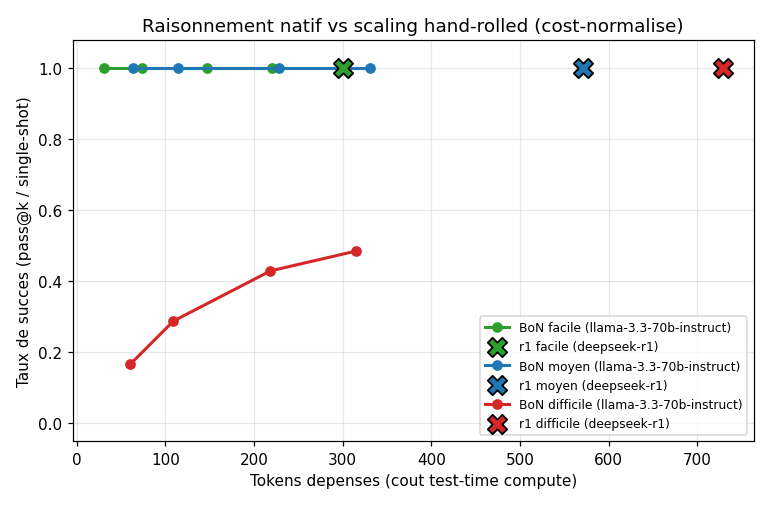

Lecture : pour chaque bucket, la courbe = BoN (scaling exterieur), la croix = r1
(raisonnement natif). Si la croix est au-dessus de la courbe au meme cout -> le raisonnement
natif gagne ; sinon -> le scaling hand-rolled est plus compute-efficace (Snell).


In [6]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
import io

fig, ax = plt.subplots(figsize=(7.0, 4.6))
couleurs = {"facile": "#2ca02c", "moyen": "#1f77b4", "difficile": "#d62728"}
for b in PROBLEMES:
    xs = [base_curve[b]["tok"][k] for k in K_LIST]
    ys = [base_curve[b]["pass"][k] for k in K_LIST]
    ax.plot(xs, ys, "-o", color=couleurs[b], linewidth=2, markersize=6,
            label=f"BoN {b} ({BASELINE_MODEL.split('/')[-1]})")
    # point du modele a raisonnement (croix) sur la meme bucket
    r_succ = sum(r[0] for r in reason[b]) / len(reason[b])
    r_tok = sum(r[1] for r in reason[b]) / len(reason[b])
    ax.scatter([r_tok], [r_succ], marker="X", s=160, color=couleurs[b],
               edgecolor="black", linewidth=1.2, zorder=5,
               label=f"r1 {b} ({REASONING_MODEL.split('/')[-1]})")
ax.set_xlabel("Tokens depenses (cout test-time compute)")
ax.set_ylabel("Taux de succes (pass@k / single-shot)")
ax.set_title("Raisonnement natif vs scaling hand-rolled (cost-normalise)")
ax.set_ylim(-0.05, 1.08); ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="lower right", ncol=1)
buf = io.BytesIO(); fig.tight_layout(); fig.savefig(buf, format="png", dpi=110); plt.close(fig)
buf.seek(0); display(Image(data=buf.read()))
print("Lecture : pour chaque bucket, la courbe = BoN (scaling exterieur), la croix = r1")
print("(raisonnement natif). Si la croix est au-dessus de la courbe au meme cout -> le raisonnement")
print("natif gagne ; sinon -> le scaling hand-rolled est plus compute-efficace (Snell).")

In [7]:
# Tableau synthetique : au cout du single-shot r1, ou en serait le BoN ?
print("=== Verdict cost-normalise (par bucket) ===")
print(f"{'bucket':11s} | {'r1 single-shot':>16s} | {'BoN @ meme cout':>16s} | gagnant")
print("-" * 70)
for b in PROBLEMES:
    r_succ = sum(r[0] for r in reason[b]) / len(reason[b])
    r_tok = sum(r[1] for r in reason[b]) / len(reason[b])
    # pass@k BoN le plus proche (en tokens) du cout r1 (interpolation naive: prend le k le plus proche)
    k_best = min(K_LIST, key=lambda k: abs(base_curve[b]["tok"][k] - r_tok))
    bon_at = base_curve[b]["pass"][k_best]
    bon_tok = base_curve[b]["tok"][k_best]
    gagnant = "r1 (raisonnement)" if r_succ > bon_at + 0.01 else \
              ("BoN (scaling)" if bon_at > r_succ + 0.01 else "egal / bruit")
    print(f"{b:11s} | {r_succ:>7.2f} ({r_tok:>5.0f} tok) | {bon_at:>7.2f} ({bon_tok:>5.0f} tok) | {gagnant}")
print("\nLecture honnete (G.2) : n petit, bruit eleve -> tracer la conclusion avec")
print("prudence. La METHODE (cost-normalise tokens-incl-reasoning) est transferable.")

=== Verdict cost-normalise (par bucket) ===
bucket      |   r1 single-shot |  BoN @ meme cout | gagnant
----------------------------------------------------------------------
facile      |    1.00 (  300 tok) |    1.00 (  220 tok) | egal / bruit
moyen       |    1.00 (  571 tok) |    1.00 (  331 tok) | egal / bruit
difficile   |    1.00 (  728 tok) |    0.48 (  314 tok) | r1 (raisonnement)

Lecture honnete (G.2) : n petit, bruit eleve -> tracer la conclusion avec
prudence. La METHODE (cost-normalise tokens-incl-reasoning) est transferable.


## 5. Limites honnetes (G.2)

- **n petit** (6 echantillons) : pass@k bruite ; les points du modele a raisonnement sont
  estimes sur 2 problemes par bucket (bruit fort). Snell utilise des milliers d'evaluations.
- **Une seule comparaison modele** (deepseek-r1 vs llama-3.3-70b) : le verdict depend du couple
  de modeles. Snell compare a un modele 14x plus gros ; ici le rapport de taille/cout differe.
- **Suite simple** : sur de l'arithmetique, le bucket difficile peut saturer chez r1 (1.0)
  tandis que le BoN plafonne — ce qui ferait gagner r1, mais c'est parce que r1 est un modele
  **plus fort**, pas seulement parce qu'il raisonne. Desintriquer "taille du modele" et
  "test-time compute natif" necessiterait une comparaison a **qualite de modele compareble**
  (exercice 2) — non resolu ici, assume franchement.
- **Cout = tokens** (approximation) : le vrai cout OpenRouter est en $, non en tokens ; on
  normalise en tokens parce que c'est model-agnostique et que les reasoning tokens sont ainsi
  comptabilises. Le cout $ depend des prix respectifs (exercice 3).

**Ce qui est demontre** : la **methodologie de comparaison cost-normalisee** (courbe tokens-vs-pass
du scaling hand-rolled + point du modele a raisonnement) — reproductible et applicable a d'autres
couples de modeles / suites plus difficiles.

## 6. Travaux pratiques

Les exercices sont a completer (convention C.1 : pas d'erreur volontaire).

### Exercice 1 : plusieurs modeles a raisonnement (frontiere)

Trace la meme comparaison cost-normalisee avec **plusieurs** modeles a raisonnement (deepseek-r1,
o3-mini, gpt-5-thinking) : chaque modele = un point. Construis la **frontiere de Pareto**
(modeles dominates elimines) tokens-vs-succes.

**Indice :** boucle sur une liste de REASONING_MODELS, collecte (tokens, succes) par bucket,
trace tous les points + enveloppe de Pareto (un point est Pareto-optimal si aucun autre n'a
a la fois moins de tokens ET plus de succes).

In [8]:
def frontiere_pareto_raisonnement(modeles):
    """Exercice 1 : points (tokens, succes) de plusieurs modeles a raisonnement + frontiere."""
    # TODO etudiant : pour chaque modele, single-shot sur PROBLEMES, collecter (tok, succ),
    # renvoyer la liste + l'indice des points Pareto-optimaux.
    return None

print(f"Exercice 1 - frontiere Pareto raisonnement : {'implemente' if False else 'a completer'}")

Exercice 1 - frontiere Pareto raisonnement : a completer


### Exercice 2 : desintriquer "taille du modele" vs "raisonnement natif"

Le verdict Phase 5 confond "r1 est plus gros/meilleur" et "r1 raisonne". Desintrique : compare
le BoN sur r1 **mode raisonnement off** (si disponible) vs r1 raisonnement **on**, au meme
budget tokens. Le delta isole l'apport du test-time compute natif.

**Indice :** certains modeles exposent un parametre "reasoning_effort" (low/medium/high) ou un
modele "non-thinking" jumeau. Compare pass@k a budget tokens egal entre effort=low et high.

In [9]:
def isoler_apport_raisonnement(model_high, model_low, enonce, attendu):
    """Exercice 2 : compare single-shot raisonnement on vs off, a budget tokens compare."""
    # TODO etudiant : appeler les deux variantes, retourner (succes_high, tok_high, succ_low, tok_low).
    return None

print(f"Exercice 2 - taille vs raisonnement : {'implemente' if False else 'a completer'}")

Exercice 2 - taille vs raisonnement : a completer


### Exercice 3 (avance) : cout en dollars (OpenRouter)

Refais la comparaison en **dollars** (pas tokens) : recupere le prix input/output/reasoning de
chaque modele (API OpenRouter `/models` ou tarifs publics) et calcule le cout $ reel de chaque
strategie. La frontiere tokens-vs-succes peut **inverser** en $ (si le modele a raisonnement est
beaucoup plus cher par token).

**Indice :** GET https://openrouter.ai/api/v1/models -> pricing.prompt/completion/completion_reasoning
par modele ; calcule cout = tok_prompt*prompt + tok_completion*completion (+ reasoning*raisonnement).

In [10]:
def cout_dollars(model, tok_prompt, tok_completion, tok_reasoning=0):
    """Exercice 3 : cout $ reel d'un appel via la tarification OpenRouter."""
    # TODO etudiant : requeter /api/v1/models, extraire pricing, calculer le cout $.
    return None

print(f"Exercice 3 - cout en dollars : {'implemente' if False else 'a completer'}")

Exercice 3 - cout en dollars : a completer


## 7. Conclusion et suite

On a compare, **a cout normalise en tokens (raisonnement inclus)**, le **scaling hand-rolled**
(BoN pass@k sur un modele standard) au **raisonnement natif** (single-shot deepseek-r1), sur la
meme suite graduee. La figure superpose la courbe tokens-vs-pass du BoN et le point du modele a
raisononnement par bucket — la **question centrale de Snell** : a cout egal, qui gagne ?

**Ce qui est demontre** : la **methodologie de comparaison cost-normalisee** — equitable
(meme suite, meme verificateur) et transferable (autres couples de modeles, autres suites).

**Limites honnetes (G.2)** : n petit, une seule comparaison de modeles, suite simple, cout en
tokens (approximation du $). Le verdict depend du couple de modeles et du bucket ; il faut le
lire avec prudence et l'etendre (exercices 1-3) avant de generaliser.

**Suite de l'epic #2926 :**
- **Phase 6** — plugin **Semantic Kernel** : integrer les moteurs (BoN/ToT/Reflexion/memory) comme
  **plugins SK** (pont series SemanticKernel), exposant le test-time scaling comme outil reutilisable.

**References :** Snell et al. 2024 (test-time compute scaling) ; NB-12 (moteurs), NB-16 (pass@k
scaling), NB-13/14/15 (routeur, memoire, ToT-CSP) de cette serie.